# Training and benchmarking FiLM with genuinely missing fate

Train a depth-two exclusive-fate FiLM with seven fate channels plus a binary **fate_missing** flag. Observed unassigned cells have seven zeros and flag 0; hidden identities have seven zeros and flag 1. Every branch, including the input residual projection, receives this encoding. The graph, global log N and curvature targets remain unchanged. Global geometry does not enter the GNN/head.

The experiment covers three comparisons:

1. **Intact quality:** full validation-graph prediction accuracy and predictive coverage versus a newly trained, matched 0% control.
2. **Masked quality:** exactly one hop-1 or hop-2 neighbor hidden, with the recipient observed; paired prediction errors, bias, and coverage across N and identities.
3. **Training robustness:** seeds × masking rates (1%, 2%, 5%), including accuracy and the sign/magnitude of conditional fate contrasts.

These are conditional information effects, not causal cell interactions. Unknown identity can be inferred from context. No biological fate is substituted when the flag is set.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ROOT=Path.cwd().resolve()
if not (ROOT/'src').is_dir(): ROOT=ROOT.parent
assert (ROOT/'src').is_dir()
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.analysis.fate_masking import (
    MaskTrainingConfig, train_masking_experiment,
    benchmark_masking_experiment, load_mask_benchmarks,
)
from src.plotting.fate_masking import (
    benchmark_tables, plot_intact_quality, plot_masked_quality,
    plot_training_robustness, plot_effect_robustness,
)

## Training settings

Every optimizer step averages an intact and randomly masked pass with equal loss weight. In the masked pass, each node is hidden independently with the same probability, including naturally unassigned cells. Masks change every batch and do not use fate, N, curvature, geometry, or crypt labels. Rates share the same random uniforms, data order and base initialization within a seed. The 0% control also performs two passes per step, so dropout, normalization passes and optimizer-step counts are comparable. Additional mask-input weights start at zero.

Each original outer training fold is split into fitting and **inner early-stopping** organoids. All variants select checkpoints by intact inner-validation transformed-target MSE. Original outer validation organoids are reserved for the benchmarks and ablations. Cached baseline/target preprocessing is reused from the original outer-fold run; it is not refitted on the inner fitting subset. Existing cohort-level outlier interpolation is retained. This is not a claim of fully nested preprocessing or causal unbiasedness.

The original model used a different training/selection protocol. The newly trained **0% control** is the direct benchmark for masking augmentation; historical checkpoint comparisons remain secondary.

In [2]:
REFERENCE_RUN=ROOT/'results_experiments/size_conditioned_exclusive/20260914_ordered_exclusive_film_depth2/exclusive'
MASKING_RUN=ROOT/'results_experiments/fate_masking/exclusive_film_v1'
FOLDS=None          # all five existing outer folds
MODEL_SEEDS=None    # all three existing seeds
TRAINING=MaskTrainingConfig(
    rates=(0., .01, .02, .05),
    masked_loss_weight=.5,
    inner_val_fraction=.15,
    inner_split_seed=8123,
    max_epochs=500,
    patience=30,
    batch_size=64,
    num_workers=0,
)
BENCHMARK_CENTERS_PER_IDENTITY=2  # stratified pair-effect diagnostics
QUALITY_CENTERS_PER_ORGANOID=16  # sampled independently of fate
BENCHMARK_SAMPLING_SEED=1701
INFERENCE_BATCH_SIZE=128
BOOTSTRAP_SAMPLES=500
MIN_ORGANOIDS=5
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(4)
RUN_TRAINING=True
RUN_BENCHMARKS=True
print('Device:',DEVICE)
print('Training:',TRAINING)
print('Default full experiment: 4 rates × 3 seeds × 5 folds = 60 checkpoints.')
print('Output:',MASKING_RUN)

Device: cuda
Training: MaskTrainingConfig(rates=(0.0, 0.01, 0.02, 0.05), masked_loss_weight=0.5, inner_val_fraction=0.15, inner_split_seed=8123, max_epochs=500, patience=30, batch_size=64, num_workers=0)
Default full experiment: 4 rates × 3 seeds × 5 folds = 60 checkpoints.
Output: /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/fate_masking/exclusive_film_v1


## Train the models

This is the expensive training step. Completed checkpoints are reused; unfinished individual models restart their training. Settings/dependency fingerprints prevent silently combining different runs. Changing training settings requires a new output directory. The existing trained models and datasets are not overwritten.

The original Gaussian loss and edge penalty are retained. The model is trained to predict curvature with missing information; there is no fate-reconstruction loss or forced agreement between intact and masked predictions.

In [3]:
if RUN_TRAINING:
    train_masking_experiment(ROOT,REFERENCE_RUN,MASKING_RUN,
        config=TRAINING,folds=FOLDS,seeds=MODEL_SEEDS,device=DEVICE)
assert (MASKING_RUN/'training_complete.json').exists(), 'Complete training first.' 

Loaded 1100 graphs; skipped 0.
=== Target outlier interpolation report ===
Quantiles: [0.005, 0.995]
target 0: range=[-0.201986, 0.236541] | outliers=4778 | replaced=4778 | fallback=42 | rejected_interp=42


/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Train fold=0, seed=42, masking rate=0
p0 seed=42 epoch=1: loss=0.51464, inner intact MSE=0.93386
p0 seed=42 epoch=2: loss=0.47102, inner intact MSE=0.88595
p0 seed=42 epoch=3: loss=0.4616, inner intact MSE=0.90679
p0 seed=42 epoch=4: loss=0.45352, inner intact MSE=0.86607
p0 seed=42 epoch=5: loss=0.44308, inner intact MSE=0.86119
p0 seed=42 epoch=6: loss=0.44179, inner intact MSE=0.90442
p0 seed=42 epoch=7: loss=0.43799, inner intact MSE=0.8538
p0 seed=42 epoch=8: loss=0.43564, inner intact MSE=0.85491
p0 seed=42 epoch=9: loss=0.43268, inner intact MSE=0.85691
p0 seed=42 epoch=10: loss=0.43518, inner intact MSE=0.85367
p0 seed=42 epoch=11: loss=0.43254, inner intact MSE=0.84866
p0 seed=42 epoch=12: loss=0.42856, inner intact MSE=0.84528
p0 seed=42 epoch=13: loss=0.42997, inner intact MSE=0.84716
p0 seed=42 epoch=14: loss=0.42763, inner intact MSE=0.84824
p0 seed=42 epoch=15: loss=0.42944, inner intact MSE=0.85569
p0 seed=42 epoch=16: loss=0.42578, inner intact MSE=0.85903
p0 seed=42 ep

## Benchmark on outer validation organoids

Intact benchmarking evaluates every cell in each full validation graph. For prediction quality and marginal calibration, recipient centers are sampled uniformly within organoid, then one source is sampled uniformly from each exact hop-1/hop-2 ring, without consulting identities. These cases are fixed across rates/seeds. Separately, identity-stratified cases cover all eight identities (including Unassigned) for pair-effect diagnostics. The center always stays observed. This separation prevents oversampling rare source identities from changing the hidden-fate prior in aggregate calibration scores.

The 0% control is evaluated on intact inputs only: its mask flag was never trained, so masking it would not define a valid unknown-fate reference. For each positive-rate model, zeroing is also evaluated as a within-model reference. There is no hypothetical-size accuracy score: only observed-size inputs have measured targets.

Saved uncertainty metrics use the predicted Gaussian in transformed-target space: NLL, standardized residual moments, and central 50%, 80%, 95% coverage. Coverage also applies after the monotone inverse transform; physical-space MSE uses inverse-transformed mean predictions. These metrics do not include model-parameter uncertainty.

In [4]:
if RUN_BENCHMARKS:
    benchmark_masking_experiment(ROOT,MASKING_RUN,
        centers_per_identity=BENCHMARK_CENTERS_PER_IDENTITY,
        quality_centers_per_organoid=QUALITY_CENTERS_PER_ORGANOID,
        sampling_seed=BENCHMARK_SAMPLING_SEED,
        batch_size=INFERENCE_BATCH_SIZE,device=DEVICE)
bench=load_mask_benchmarks(MASKING_RUN)
tables=benchmark_tables(bench,bootstrap_samples=BOOTSTRAP_SAMPLES)
for name,table in tables.items():
    table.to_csv(MASKING_RUN/'benchmarks'/f'summary_{name}.csv',index=False)
display(tables['seed_quality'])

Loaded 1100 graphs; skipped 0.
=== Target outlier interpolation report ===
Quantiles: [0.005, 0.995]
target 0: range=[-0.201986, 0.236541] | outliers=4778 | replaced=4778 | fallback=42 | rejected_interp=42
Benchmarked fold_0_seed_42_p0
Benchmarked fold_0_seed_43_p0
Benchmarked fold_0_seed_44_p0
Benchmarked fold_0_seed_42_p0.01
Benchmarked fold_0_seed_43_p0.01
Benchmarked fold_0_seed_44_p0.01
Benchmarked fold_0_seed_42_p0.02
Benchmarked fold_0_seed_43_p0.02
Benchmarked fold_0_seed_44_p0.02
Benchmarked fold_0_seed_42_p0.05
Benchmarked fold_0_seed_43_p0.05
Benchmarked fold_0_seed_44_p0.05
Benchmarked fold_1_seed_42_p0
Benchmarked fold_1_seed_43_p0
Benchmarked fold_1_seed_44_p0
Benchmarked fold_1_seed_42_p0.01
Benchmarked fold_1_seed_43_p0.01
Benchmarked fold_1_seed_44_p0.01
Benchmarked fold_1_seed_42_p0.02
Benchmarked fold_1_seed_43_p0.02
Benchmarked fold_1_seed_44_p0.02
Benchmarked fold_1_seed_42_p0.05
Benchmarked fold_1_seed_43_p0.05
Benchmarked fold_1_seed_44_p0.05
Benchmarked fold_2_s

,mask_rate,seed,mse_mu,mse_z,bias_z,nll_z,coverage_50,coverage_80,coverage_95,standardized_error,standardized_error2
0,0.00,42,0.002173,0.783782,0.005366,1.284247,0.488718,0.797863,0.947237,0.009647,1.044866
1,0.00,43,0.002166,0.780060,-0.009681,1.282080,0.492625,0.803986,0.950712,-0.009898,1.016164
2,0.00,44,0.002160,0.779485,-0.008190,1.283528,0.493755,0.804192,0.950247,-0.006417,1.019507
3,0.01,42,0.002172,0.781419,-0.008809,1.285755,0.488213,0.797803,0.947020,-0.004924,1.051654
4,0.01,43,0.002163,0.779158,-0.008182,1.281286,0.493858,0.804537,0.950966,-0.007188,1.013558
5,0.01,44,0.002161,0.779377,-0.001569,1.283593,0.491293,0.802568,0.949742,0.000166,1.024301
6,0.02,42,0.002169,0.780378,-0.013863,1.283414,0.492103,0.801524,0.949162,-0.012172,1.028764
7,0.02,43,0.002167,0.780004,-0.015696,1.282498,0.493349,0.804495,0.950848,-0.016755,1.015200
8,0.02,44,0.002162,0.778654,-0.006135,1.283471,0.495887,0.807175,0.951559,-0.004445,1.007542
9,0.05,42,0.002176,0.783206,-0.006191,1.285280,0.489411,0.799731,0.948508,-0.002594,1.036784


## 1. Intact prediction quality

MSE is computed within organoid, then organoids receive equal weight. Curvature errors are on the baseline-residual scale; the unchanged per-organoid baseline cancels from prediction errors. Shading is a pointwise organoid bootstrap after averaging repeated seeds. It conditions on fitted models; seed spread is shown separately.

All-center curves are displayed here. `tables['intact']` additionally contains each center identity and size bin, including bias, NLL, standardized errors, and 50/80/95% coverage.

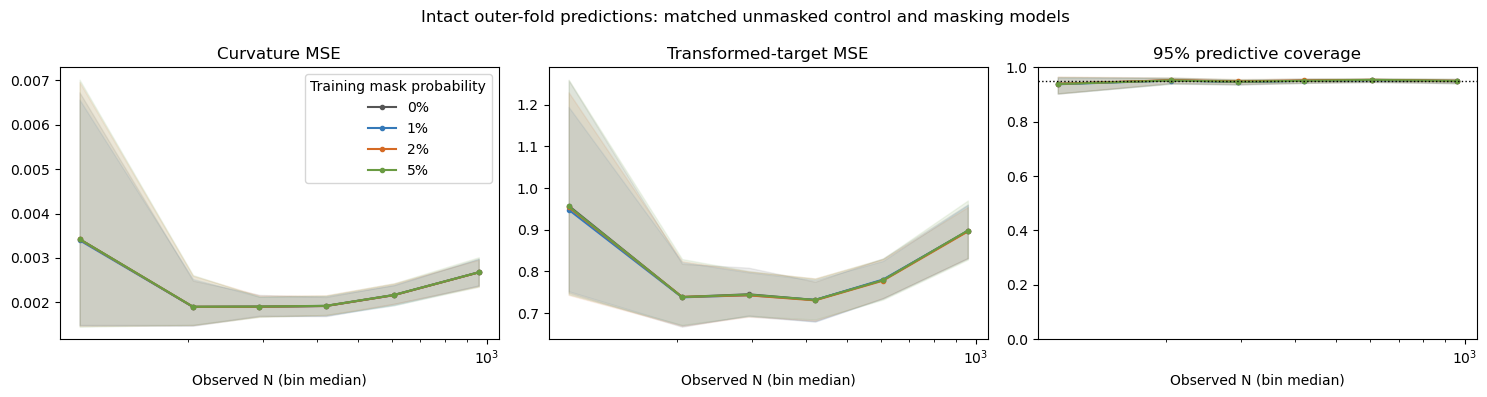

In [5]:
fig=plot_intact_quality(tables)
fig.savefig(MASKING_RUN/'figures/01_intact_quality.png',dpi=160,bbox_inches='tight')
plt.show()

## 2. Exactly-one-neighbor masked prediction quality

Solid lines show intact predictions for the **same selected recipient/source cases** used by dashed masked lines. This avoids comparing the masked cohort against a different collection of cells. The error-change panel uses paired differences, averaging cases and seeds within organoid.

Detailed center/source/hop/N quality strata are saved in `summary_pair_quality.csv`; low-support strata should not be interpreted as reliable calibration estimates. Negative signed curvature contrasts and increases/decreases in prediction error are different quantities.

Masked errors stratified by the original hidden source identity can have nonzero mean even for a correctly calibrated conditional predictor: the predictor is not told the identity used to define that stratum. Use the fate-independent quality sample for marginal calibration; pair-stratified errors are descriptive diagnostics.

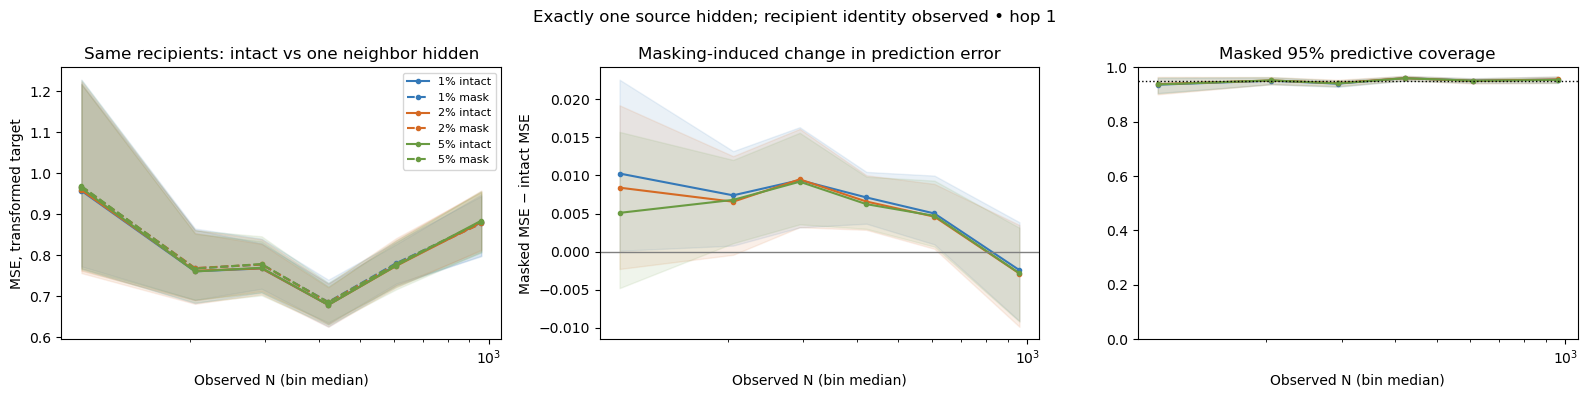

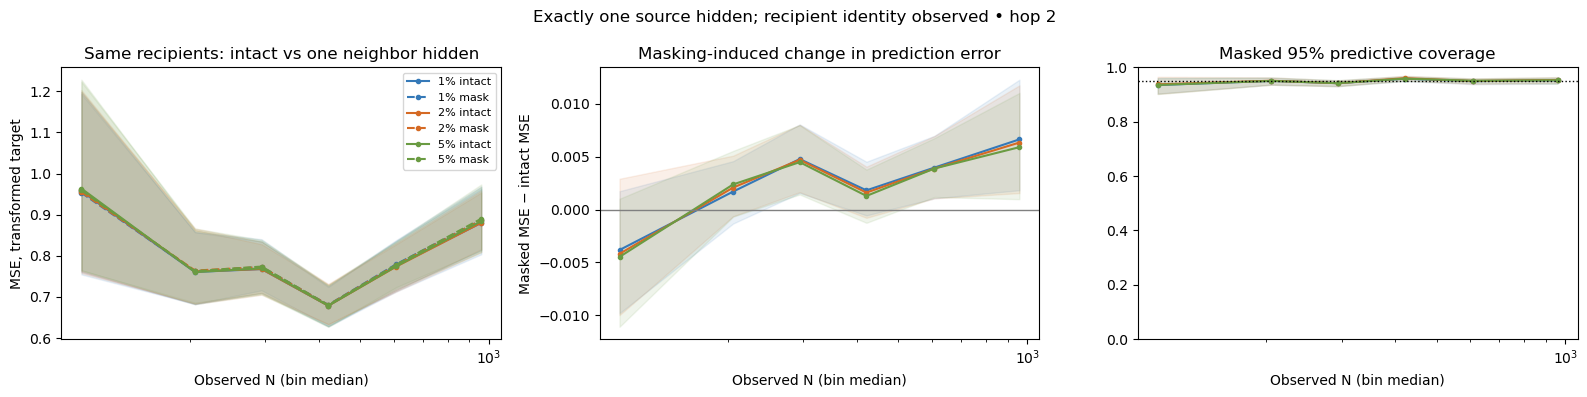

,mask_rate,center_marker,source_marker_name,hop,size_bin,mean,ci_low,ci_high,n_organoids,n_rows,state,metric
0,0.01,Agr2,Agr2,1,0,1.327675,0.835418,1.865762,38,165,intact,mse_z
1,0.01,Agr2,Agr2,1,1,0.937909,0.711897,1.199258,107,477,intact,mse_z
2,0.01,Agr2,Agr2,1,2,0.990494,0.784809,1.261503,118,537,intact,mse_z
3,0.01,Agr2,Agr2,1,3,1.064685,0.855375,1.302234,135,543,intact,mse_z
4,0.01,Agr2,Agr2,1,4,0.842302,0.654087,1.039922,138,567,intact,mse_z
5,0.01,Agr2,Agr2,1,5,1.009805,0.764416,1.309177,65,255,intact,mse_z
6,0.01,Agr2,Agr2,2,0,1.328937,0.865336,1.860861,51,246,intact,mse_z
7,0.01,Agr2,Agr2,2,1,0.860631,0.685509,1.059520,138,675,intact,mse_z
8,0.01,Agr2,Agr2,2,2,0.927867,0.738999,1.129877,162,762,intact,mse_z
9,0.01,Agr2,Agr2,2,3,1.006942,0.853751,1.168890,181,825,intact,mse_z


In [6]:
for hop in (1,2):
    fig=plot_masked_quality(tables,hop=hop)
    fig.savefig(MASKING_RUN/f'figures/02_masked_quality_hop{hop}.png',dpi=160,bbox_inches='tight')
    plt.show()
display(tables['pair_quality'].query('n_organoids >= @MIN_ORGANOIDS').head(16))

## 3. Training robustness

Each line below represents one model seed, aggregated across held-out organoids. Compare both intact performance relative to the newly trained 0% control and masked prediction quality across rates. The following identity matrix shows sign consistency of **pooled observed-size** masking effects across all trained positive rates and seeds. Values near 0 or 1 indicate agreement on direction; values near 0.5 indicate disagreement. This is descriptive, not a significance test; tiny effects can flip sign.

`summary_seed_effects.csv` retains effect magnitudes and support. `summary_effects.csv` also retains N-bin profiles for every rate/seed and center/source/hop combination, so pooled sign agreement need not be mistaken for agreement of curve shape.

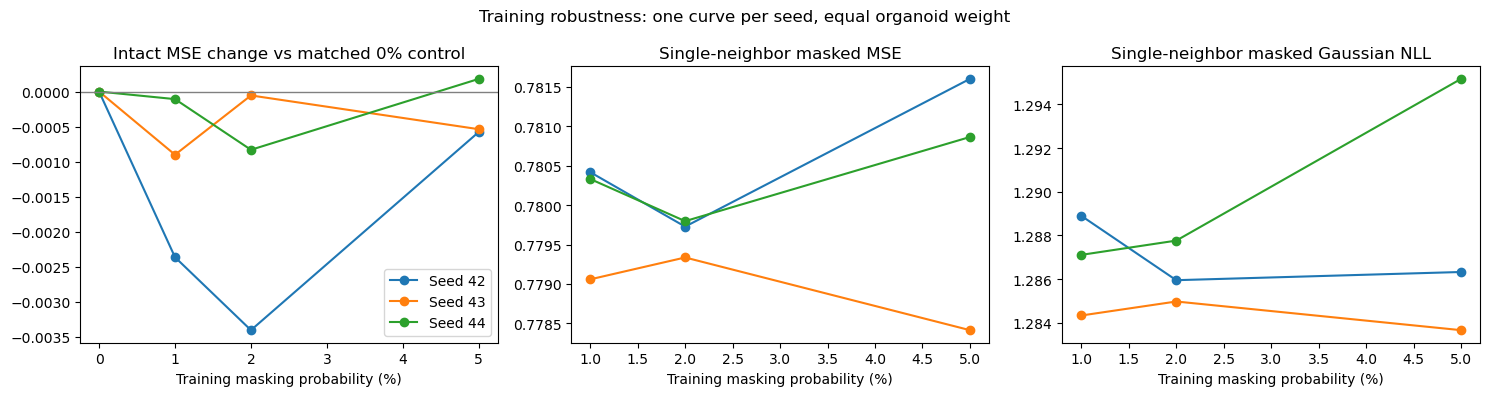

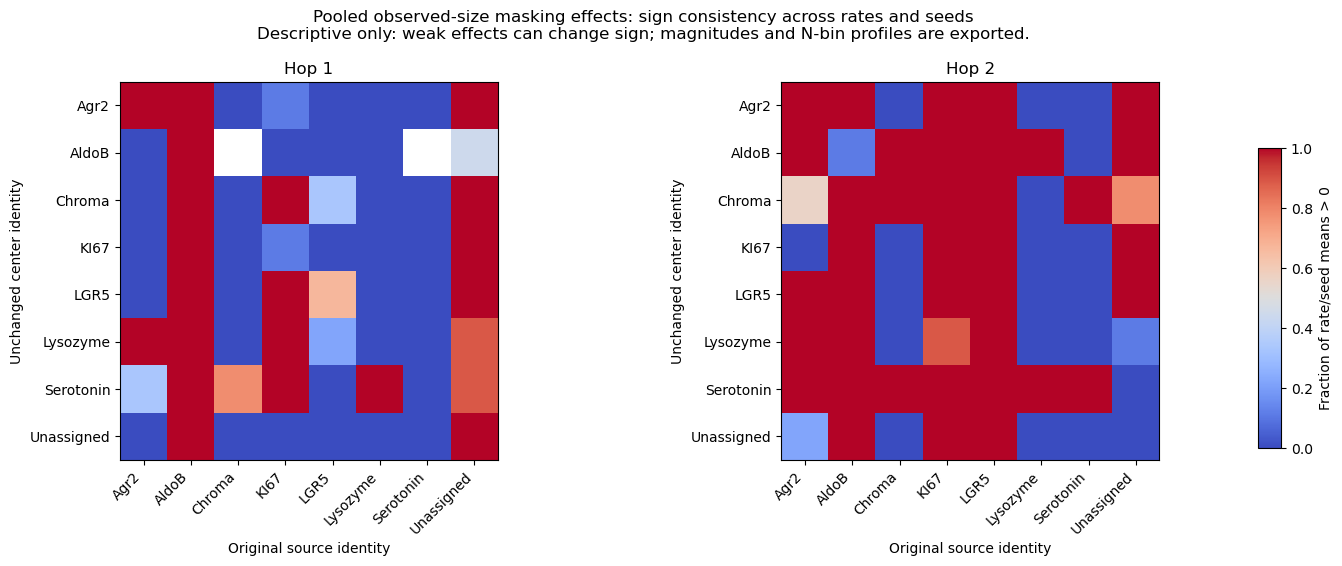

,mask_rate,seed,center_marker,source_marker_name,hop,effect,delta_mse_z,n_organoids
0,0.01,42,Agr2,Agr2,1,0.012277,-0.001581,601
1,0.01,42,Agr2,Agr2,2,0.013654,-0.001819,779
2,0.01,42,Agr2,AldoB,1,0.029831,0.007499,444
3,0.01,42,Agr2,AldoB,2,0.019918,-0.007960,586
4,0.01,42,Agr2,Chroma,1,-0.240566,0.315364,26
5,0.01,42,Agr2,Chroma,2,-0.083300,0.090973,76
6,0.01,42,Agr2,KI67,1,-0.006184,0.001394,716
7,0.01,42,Agr2,KI67,2,0.011726,0.006077,826
8,0.01,42,Agr2,LGR5,1,-0.020491,0.023636,546
9,0.01,42,Agr2,LGR5,2,0.022362,-0.000264,621


In [7]:
fig=plot_training_robustness(bench,tables)
fig.savefig(MASKING_RUN/'figures/03_rate_seed_quality.png',dpi=160,bbox_inches='tight')
plt.show()
fig=plot_effect_robustness(bench,tables,min_organoids=MIN_ORGANOIDS)
fig.savefig(MASKING_RUN/'figures/04_effect_sign_robustness.png',dpi=160,bbox_inches='tight')
plt.show()
display(tables['seed_effects'].head(16))

## Continue with static and swept masking ablation

Open **exclusive_replacement_ablation.ipynb**, set `MASKING_RUN` to this directory, and choose a positive trained masking rate. That notebook reconstructs the exact saved replacement cases and reuses their replacement weights. It evaluates zeroing, both replacement mixtures and masking **within the same masking-trained checkpoint**, keeping historical model results separately labelled.

Masking curves retain the original replacement-supported cohort for the four-way comparison. This is a comparability restriction; missing-fate inference itself does not require donor matches. No rate is automatically selected from the outer validation benchmark—any selection after inspecting it is exploratory.